<a href="https://colab.research.google.com/github/Andres-Acuna/dl_deforestation/blob/main/Deforestation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Deforestación

### Cargamos Archivos para Entrenamiento

In [27]:
from google.colab import drive
import zipfile
import os
import shutil

# 1. Conectar Google Drive
drive.mount('/content/drive')

# 2. Rutas de los archivos
ruta_zip = '/content/drive/MyDrive/Colab Notebooks/deforestation/train-jpg.zip'
ruta_csv = '/content/drive/MyDrive/Colab Notebooks/deforestation/train_classes_encoded.csv'

# 3. Descomprimir las imágenes y copiar el CSV
print("Descomprimiendo imágenes... (esto toma 1-2 minutos)")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("¡Imágenes descomprimidas!")

# 4. Copiar el CSV usando shutil en lugar del comando de consola
shutil.copy(ruta_csv, '/content/train_classes_encoded.csv')
print("CSV copiado con éxito y listo para usar.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descomprimiendo imágenes... (esto toma 1-2 minutos)
¡Imágenes descomprimidas!
CSV copiado con éxito y listo para usar.


Total de imágenes en el dataset: 40479
Total de clases (etiquetas) únicas: 17



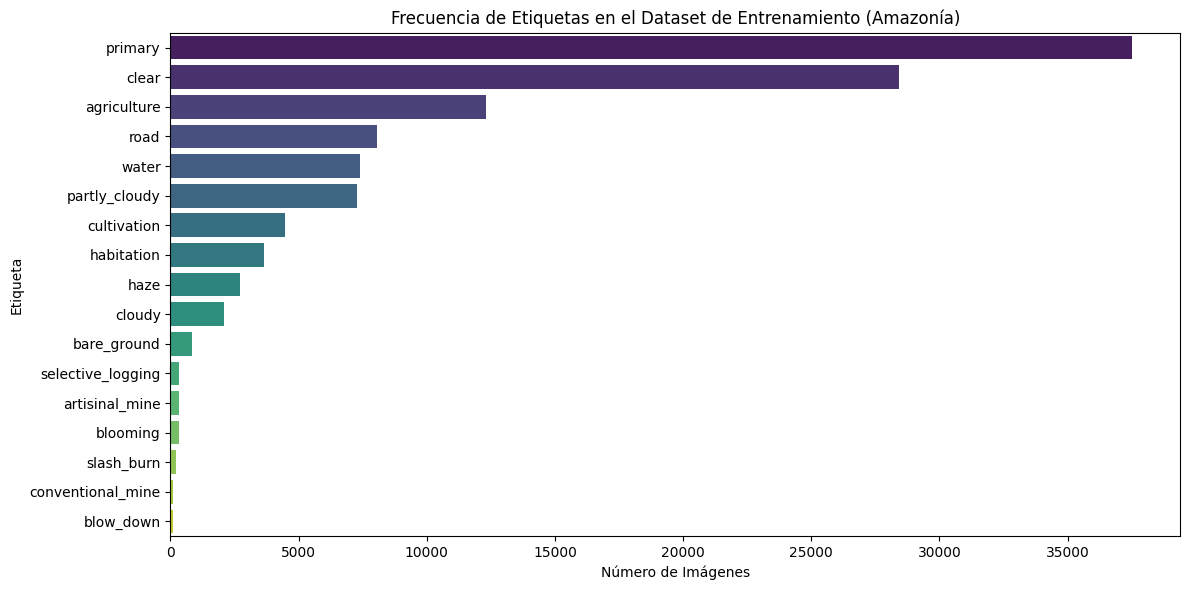

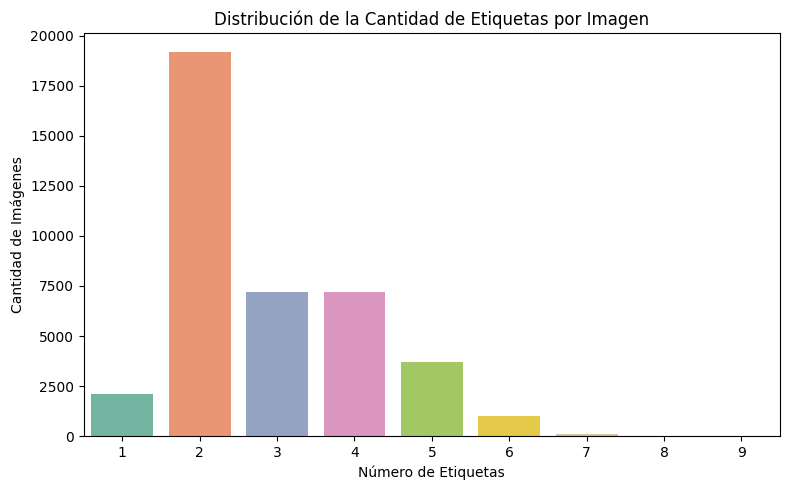


Cargando una imagen de muestra para cada etiqueta...


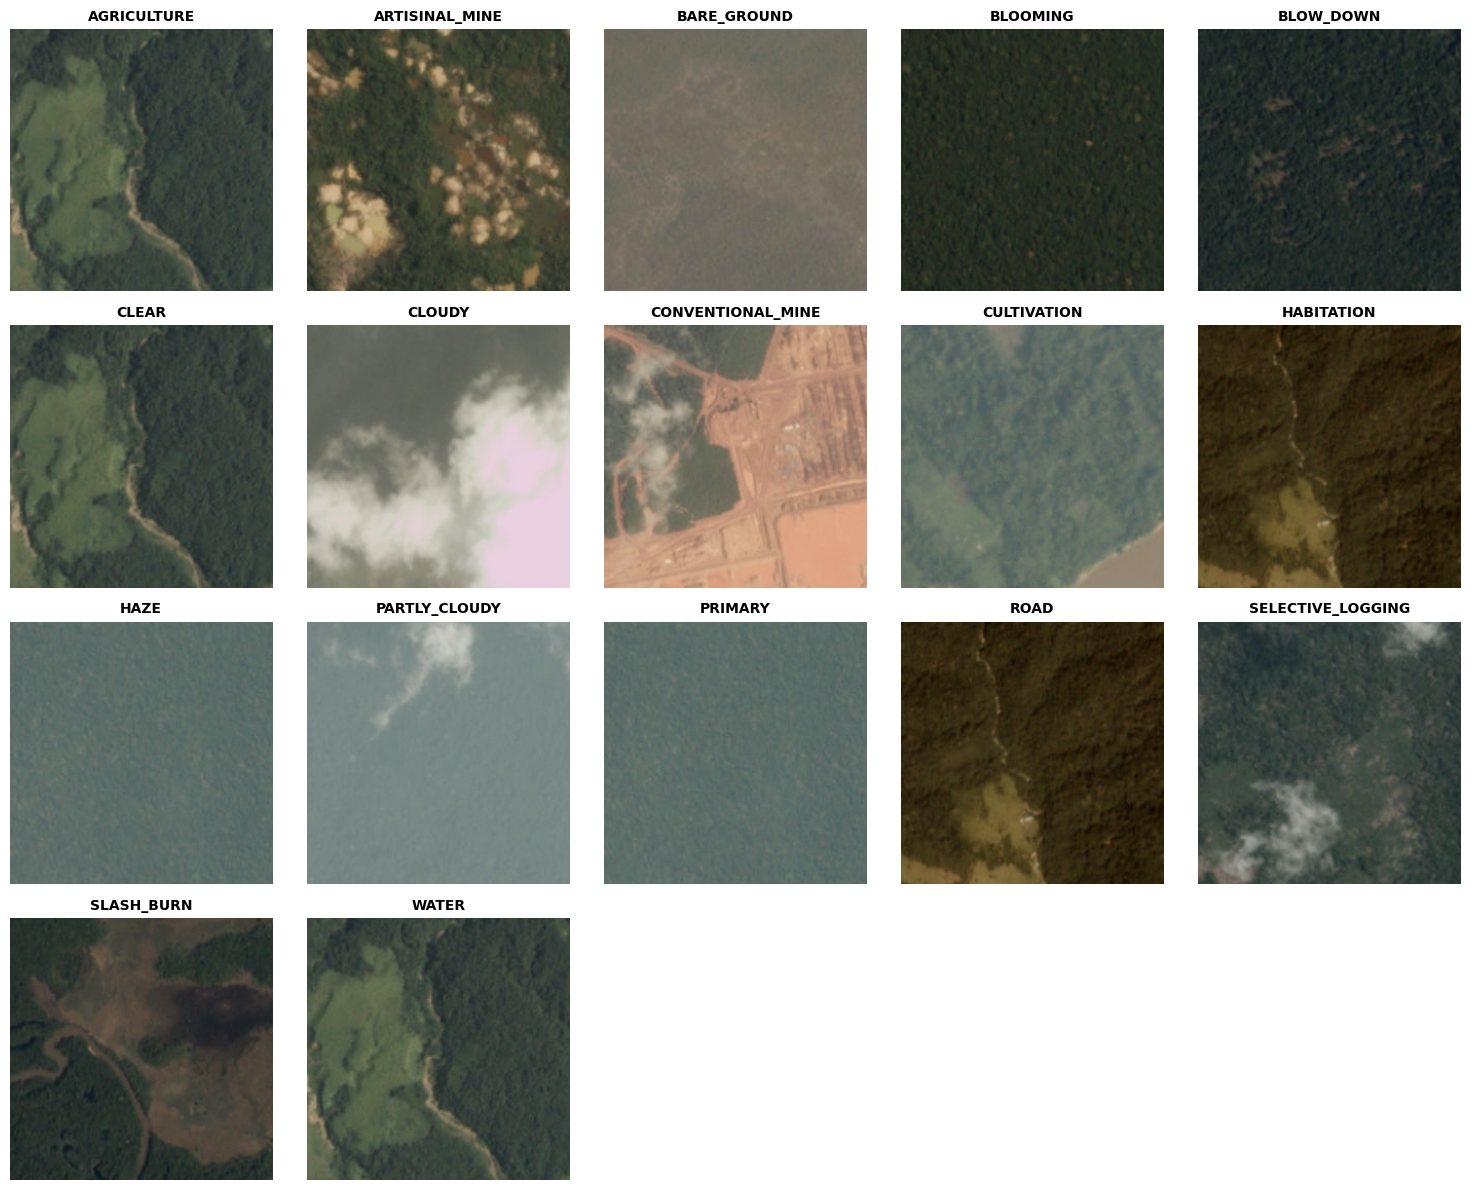

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import math

# ==========================================
# 1. Cargar los Datos
# ==========================================
df = pd.read_csv('/content/train_classes_encoded.csv')

# Extraer los nombres de las etiquetas (todas las columnas menos 'image_name')
tags = df.columns[1:]

print(f"Total de imágenes en el dataset: {len(df)}")
print(f"Total de clases (etiquetas) únicas: {len(tags)}\n")

# ==========================================
# 2. Gráfico: Frecuencia de cada Etiqueta
# ==========================================
# Sumar los 1s de cada columna para saber cuántas veces aparece cada etiqueta
tag_counts = df[tags].sum().sort_values(ascending=False)
tag_df = tag_counts.reset_index()
tag_df.columns = ['tag', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='tag', data=tag_df, palette='viridis')
plt.title('Frecuencia de Etiquetas en el Dataset de Entrenamiento (Amazonía)')
plt.xlabel('Número de Imágenes')
plt.ylabel('Etiqueta')
plt.tight_layout()
plt.show()

# ==========================================
# 3. Gráfico: Cantidad de Etiquetas por Imagen
# ==========================================
# Sumar los 1s por fila para saber cuántas etiquetas tiene cada imagen
df['num_tags'] = df[tags].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.countplot(x='num_tags', data=df, palette='Set2')
plt.title('Distribución de la Cantidad de Etiquetas por Imagen')
plt.xlabel('Número de Etiquetas')
plt.ylabel('Cantidad de Imágenes')
plt.tight_layout()
plt.show()

# ==========================================
# 4. Visualización: Una muestra por cada clase
# ==========================================
print("\nCargando una imagen de muestra para cada etiqueta...")

cols = 5
rows = math.ceil(len(tags) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()

img_folder = '/content/train-jpg'

for i, tag in enumerate(tags):
    # Buscar la primera fila (imagen) donde esta etiqueta tenga un 1
    sample_row = df[df[tag] == 1].iloc[0]
    img_name = sample_row['image_name'] + '.jpg'
    img_path = os.path.join(img_folder, img_name)

    ax = axes[i]

    try:
        # Cargar imagen y asegurar que esté en RGB
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.set_title(tag.upper(), fontsize=10, fontweight='bold')
    except FileNotFoundError:
        ax.text(0.5, 0.5, 'Imagen no\nencontrada', ha='center', va='center')
        ax.set_title(tag.upper())

    ax.axis('off')

# Ocultar los recuadros vacíos si sobran en la cuadrícula
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [29]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==========================================
# 1. PREPARACIÓN DE DATOS (DATA LOADER)
# ==========================================
class PlanetDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = self.dataframe['image_name'].values
        self.labels = self.dataframe.iloc[:, 1:].values.astype('float32')

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # Leer desde la carpeta temporal de Colab
        img_name = self.image_names[idx] + '.jpg'
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label)

# Data Augmentation básico
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Configurando DataLoaders...")
df_encoded = pd.read_csv('/content/train_classes_encoded.csv')
train_df, val_df = train_test_split(df_encoded, test_size=0.2, random_state=42)

img_folder = '/content/train-jpg'

train_dataset = PlanetDataset(train_df, img_folder, transform=train_transforms)
val_dataset = PlanetDataset(val_df, img_folder, transform=val_transforms)

BATCH_SIZE = 32
# Usamos num_workers=2 porque en Colab (Linux) funciona perfecto y acelera la carga
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Lotes para entrenar: {len(train_loader)}")

# ==========================================
# 2. DEFINICIÓN DEL MODELO (RESNET-50)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- Entrenando en: {device} ---")

class PlanetResNet(nn.Module):
    def __init__(self, num_classes=17):
        super(PlanetResNet, self).__init__()
        # Descargar modelo pre-entrenado
        self.resnet = models.resnet50(pretrained=True)
        # Congelar capas base
        for param in self.resnet.parameters():
            param.requires_grad = False
        # Reemplazar última capa para nuestras 17 clases
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)
        # Descongelar esta nueva capa
        for param in self.resnet.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.resnet(x)

model = PlanetResNet(num_classes=17).to(device)

# ==========================================
# 3. CICLO DE ENTRENAMIENTO
# ==========================================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.resnet.fc.parameters(), lr=0.001)

EPOCHS = 6

print("\n¡Iniciando entrenamiento!")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Época {epoch+1}/{EPOCHS}')

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)
    print(f"Fin Época {epoch+1} - Pérdida de Entrenamiento: {epoch_loss:.4f}")

# Guardar el modelo en tu Google Drive (en la carpeta "Colab Notebooks" que mencionaste)
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/modelo_planet_resnet50.pth')
print("\n¡Modelo guardado exitosamente en tu Google Drive!")

Configurando DataLoaders...
Lotes para entrenar: 1012

--- Entrenando en: cuda ---

¡Iniciando entrenamiento!


Época 1/6: 100%|██████████| 1012/1012 [02:30<00:00,  6.73it/s, loss=0.133]


Fin Época 1 - Pérdida de Entrenamiento: 0.1527


Época 2/6: 100%|██████████| 1012/1012 [02:29<00:00,  6.75it/s, loss=0.11]


Fin Época 2 - Pérdida de Entrenamiento: 0.1360


...

Fin Época 4 - Pérdida de Entrenamiento: 0.1304


Época 5/6: 100%|██████████| 1012/1012 [02:30<00:00,  6.73it/s, loss=0.12]


Fin Época 5 - Pérdida de Entrenamiento: 0.1301


Época 6/6: 100%|██████████| 1012/1012 [02:30<00:00,  6.70it/s, loss=0.118]


Fin Época 6 - Pérdida de Entrenamiento: 0.1286

¡Modelo guardado exitosamente en tu Google Drive!


In [30]:
import torch
import numpy as np
from sklearn.metrics import fbeta_score, classification_report
import warnings
warnings.filterwarnings('ignore') # Para ocultar advertencias de formato

# ==========================================
# EVALUACIÓN DEL MODELO Y MÉTRICAS
# ==========================================

# 1. Poner el modelo en modo "evaluación"
model.eval()

all_preds = []
all_targets = []

print("Evaluando el modelo en el set de validación (esto tomará 1 o 2 minutos)...")

# 2. Desactivar el cálculo de gradientes (ahorra memoria y acelera)
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Validando"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Pasar las imágenes por la red
        outputs = model(inputs)

        # Aplicar Sigmoide para convertir a probabilidades (0 a 1)
        probs = torch.sigmoid(outputs)

        # Umbral: Si la probabilidad es > 50%, predecimos que la etiqueta existe (1)
        preds = (probs > 0.5).int()

        # Guardar resultados
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Extraer los nombres de las etiquetas desde el DataFrame original
tags_names = train_df.columns[1:].tolist()

# 3. Calcular Métrica F2-Score
# beta=2 le da más peso a los Falsos Negativos (importante para no omitir deforestación)
f2 = fbeta_score(all_targets, all_preds, beta=2, average='samples')

print(f"\n" + "="*50)
print(f"🥇 F2-Score Global del Modelo: {f2:.4f}")
print("="*50 + "\n")

# 4. Reporte Detallado por Clase
print("Reporte detallado por clase:")
print(classification_report(all_targets, all_preds, target_names=tags_names, zero_division=0))

Evaluando el modelo en el set de validación (esto tomará 1 o 2 minutos)...


Validando: 100%|██████████| 253/253 [00:35<00:00,  7.06it/s]



🥇 F2-Score Global del Modelo: 0.8584

Reporte detallado por clase:
                   precision    recall  f1-score   support

      agriculture       0.77      0.83      0.80      2441
   artisinal_mine       0.80      0.59      0.68        70
      bare_ground       0.49      0.17      0.25       175
         blooming       0.00      0.00      0.00        64
        blow_down       0.00      0.00      0.00        25
            clear       0.95      0.94      0.94      5728
           cloudy       0.73      0.89      0.80       395
conventional_mine       1.00      0.36      0.53        22
      cultivation       0.69      0.11      0.19       864
       habitation       0.70      0.56      0.62       743
             haze       0.77      0.46      0.58       533
    partly_cloudy       0.80      0.83      0.81      1440
          primary       0.99      0.96      0.97      7507
             road       0.76      0.77      0.76      1568
selective_logging       0.17      0.03      0.

### Predicción de nuevas imagenes

Descargando imagen de prueba y analizando...


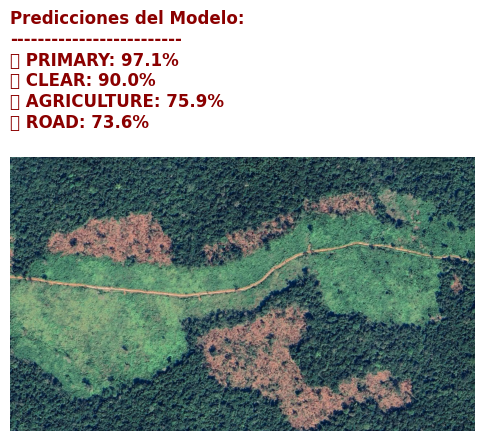

In [31]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# ==========================================
# FUNCIÓN DE PREDICCIÓN PARA NUEVAS IMÁGENES
# ==========================================

def predecir_deforestacion(image_path_or_url, model, tags_names, device, is_url=False):
    # 1. Cargar la imagen (desde internet o desde el disco)
    if is_url:
        response = requests.get(image_path_or_url)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(image_path_or_url).convert('RGB')

    # 2. Aplicar las mismas transformaciones de validación
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Añadir dimensión extra simulando un "batch de 1 sola imagen"
    image_tensor = transform(image).unsqueeze(0).to(device)

    # 3. Pasar por el modelo
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()

    # 4. Filtrar y ordenar las etiquetas que superen el 50% de probabilidad
    predicciones = {tags_names[i]: probs[i] for i in range(len(tags_names)) if probs[i] > 0.5}
    predicciones_ordenadas = dict(sorted(predicciones.items(), key=lambda item: item[1], reverse=True))

    # 5. Visualizar la imagen con sus etiquetas predichas
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')

    texto_pred = "Predicciones del Modelo:\n" + "-"*25 + "\n"
    if not predicciones_ordenadas:
        texto_pred += "Ninguna etiqueta superó el 50%"
    else:
        for tag, prob in predicciones_ordenadas.items():
            texto_pred += f"✅ {tag.upper()}: {prob*100:.1f}%\n"

    plt.title(texto_pred, loc='left', fontsize=12, fontweight='bold', color='darkred')
    plt.show()

# ==========================================
# PRUEBA: EVALUANDO UNA IMAGEN DE COLOMBIA
# ==========================================
# Nota: Para tu presentación final, puedes subir a Colab una imagen JPG
# recortada de Google Earth de una zona deforestada en Guaviare o Caquetá.
# Por ahora, usemos una imagen de prueba directamente desde internet:

url_imagen_prueba = "https://projects.mongabay.lat/2025/vias-colombia/media/images/cover-photo.webp"

print("Descargando imagen de prueba y analizando...")
predecir_deforestacion(url_imagen_prueba, model, tags_names, device, is_url=True)

Descargando imagen de prueba y analizando...


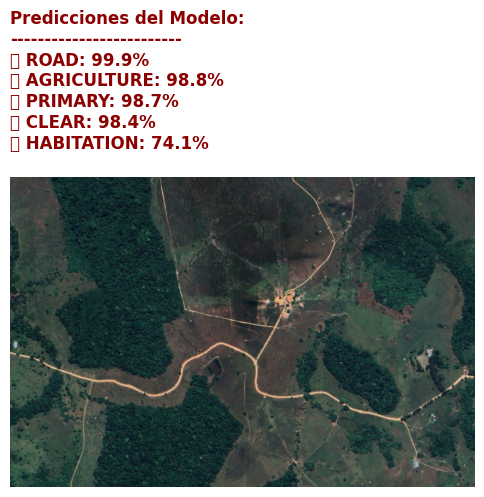

In [32]:

url_imagen_prueba = "https://imgs.mongabay.com/wp-content/uploads/sites/25/2025/06/14163711/Foto-32-1200x800.png"

print("Descargando imagen de prueba y analizando...")
predecir_deforestacion(url_imagen_prueba, model, tags_names, device, is_url=True)

Descargando imagen de prueba y analizando...


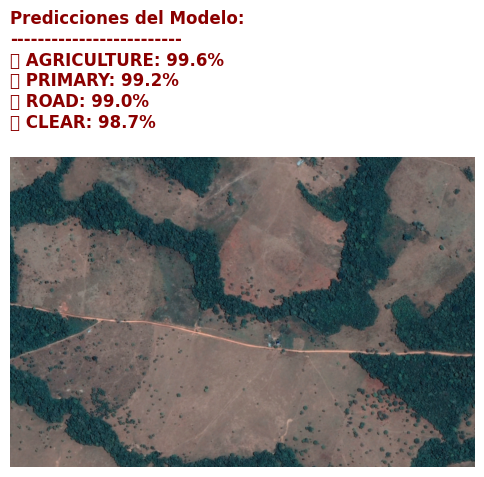

In [33]:

url_imagen_prueba = "https://imgs.mongabay.com/wp-content/uploads/sites/25/2025/06/13232417/Foto-36-1200x800.png"

print("Descargando imagen de prueba y analizando...")
predecir_deforestacion(url_imagen_prueba, model, tags_names, device, is_url=True)